# SEMBRA — Voltage-Controlled

**Surrogate for Elastomer Membrane Behavior under Radial loading and Actuation**

This notebook is the voltage-controlled interface to the SEMBRA v2 surrogate framework. Given three loading parameters, it returns the equilibrium configuration, stability classification, and failure-mode diagnostics of an inflated dielectric elastomer membrane under combined mechanical and electrical loading — evaluated in milliseconds by trained surrogates in place of direct numerical continuation.

The three loading parameters are:

- **`alpha`** (α) — the Ogden hyperelastic exponent. Admissible range **[1.2, 2.0]**.
- **`Phi`** (Φ) — the voltage-controlled electrical loading parameter. Admissible range **[0.0, 0.42]**; `Phi = 0.0` recovers the purely mechanical case.
- **`p`** — the normalized inflation pressure. Strictly **greater than zero**; no upper bound is enforced.

Run the setup cell below once, then edit the query cell and run the results cell.

In [1]:
import warnings

warnings.simplefilter("ignore")  # silence known-noisy import messages only

%matplotlib inline

# Path bootstrap: if the package is not pip-installed, make it importable from
# the repository layout (this notebook lives in <package>/notebooks/).
import sys
from pathlib import Path

_cwd = Path.cwd()
for _candidate in (_cwd, _cwd.parent):
    if (_candidate / "sembra_vc" / "__init__.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break

from sembra_vc.wrapper import predict
from sembra_vc.utils import (
    format_prediction_report,
    plot_stress_field,
    plot_design_space,
)

# Warm-up: run one prediction so the first real query below is fast.
_ = predict(1.6, 0.1, 0.4)

## Query

Edit the three loading parameters below and run the cell. These are the only values intended for modification; no other cell requires editing.

In [2]:
alpha = 1.6
Phi = 0.19
p = 0.9

## Results

Running the cell below evaluates the query and renders the output in three parts: a formatted text report (equilibrium state, stability and failure-mode diagnostics, and the equilibrium residual); the principal-stress field σ₁ and σ₂ on the deformed membrane cross-section; and the location of the query within the (Φ, p) design space at the selected α, relative to the fold (det H = 0) and wrinkling (t₂ = 0) boundaries.

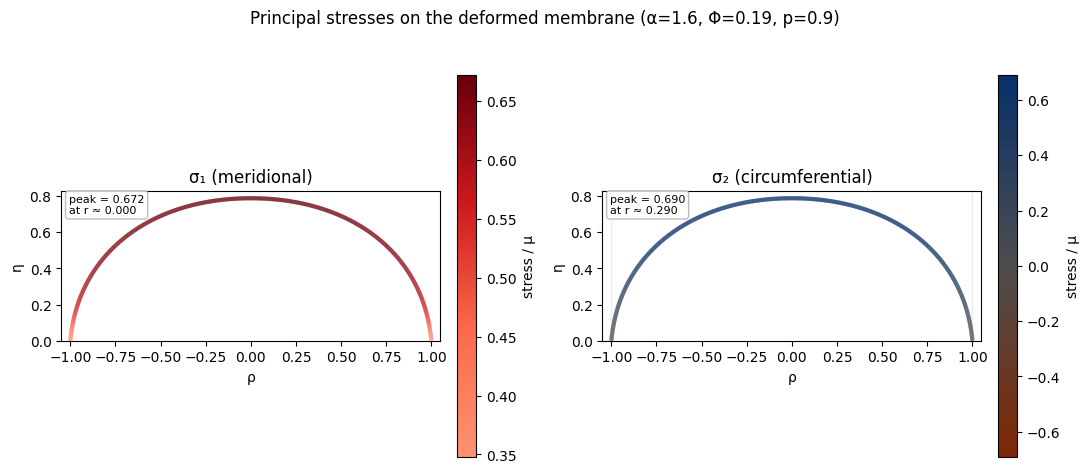

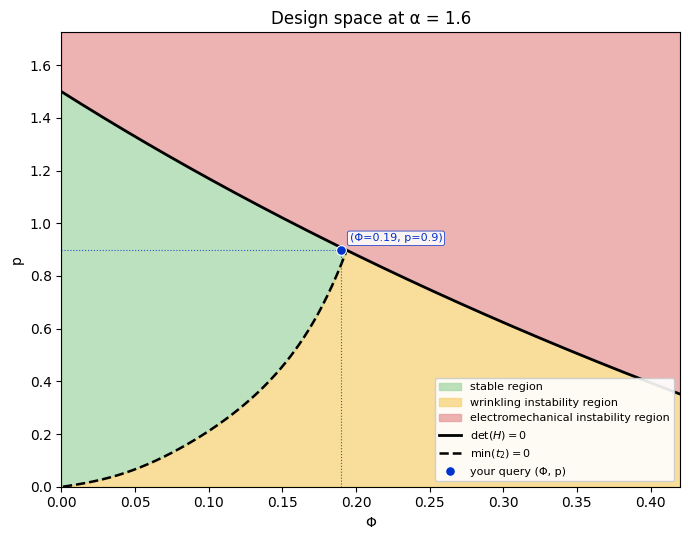

In [3]:
import matplotlib.pyplot as plt
from IPython.display import HTML, display

result = predict(alpha, Phi, p)

display(HTML("<pre style='font-family:monospace;font-size:13px;line-height:1.4'>"
             + format_prediction_report(result) + "</pre>"))

fig_stress = plot_stress_field(result)
fig_design = plot_design_space(result)
display(fig_stress)
display(fig_design)
plt.close(fig_stress)
plt.close(fig_design)